## Initialization

In [1]:
%load_ext autoreload
%autoreload 2
%autosave 0
%precision %g

import sys, os, glob, time
import re
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.lines as lines
import functools as ft
import numpy as np
import numpy.random as rnd
import scipy.integrate as integ
import qiskit as qk
import qiskit_aer as aer
import qiskit_algorithms as qalgo
import qiskit_ibm_runtime as qkrun
import qiskit_experiments as qkexp
import qiskit_braket_provider as braket

# Launch Wolfram language interface
# from wolframclient.evaluation import WolframLanguageSession
# from wolframclient.language import wl, wlexpr
# wl_session = WolframLanguageSession()

from tqdm import tqdm

import sys

sys.path.append("../")

# Directories
# if os.uname().sysname == 'Linux':
#     base_dir = os.path.expanduser("~/sn-quant/")
# else:
#     base_dir = os.path.expanduser("~/Dropbox/sn-quant/jk/")

base_dir = os.path.join("../", "joachim")
os.chdir(base_dir)

# set up matplotlib
%matplotlib inline
# matplotlib.rcParams['text.usetex']    = True
# matplotlib.rcParams['text.latex.preamble'] = r'\usepackage{amsmath,amssymb}'
matplotlib.rcParams['font.family']    = 'serif'
matplotlib.rcParams['font.size']      = '16'
# matplotlib.rcParams['figure.figsize'] = 6.4, 4.8
matplotlib.rcParams['figure.figsize'] = 16, 8

# Unit conversion and physical constants
class my_units:
    # Energy and mass
    eV     = 1.
    keV    = 1.e3
    MeV    = 1.e6
    GeV    = 1.e9
    TeV    = 1.e12
    PeV    = 1.e15
    kg     = 5.62e35*eV
    grams  = 0.001*kg
    Kelvin = 8.617333262e-5       # PDG 2022
    Joule  = 1/1.602176634e-19*eV # PDG 2022 [exact]
    erg    = 1e-7*Joule
    
    # Length and time
    m     = 5.076e6
    meter = m
    km    = 1000*m
    cm    = 0.01*m
    nm    = 1.e-9*m
    fm    = 1.e-15*m
    AU    = 1.4960e11*m
    pc    = 30.857e15*m
    kpc   = 1.e3*pc
    Mpc   = 1.e6*pc
    Gpc   = 1.e9*pc
    ly    = 9460730472580800*m  # light year
    sec   = 1.523e15
    hours = 3600*sec
    days  = 24*hours
    yrs   = 365*days
    Hz    = 1./sec
    kHz   = 1.e3*Hz
    MHz   = 1.e6*Hz
    GHz   = 1.e9*Hz
    
    barn  = 1.e-24*cm**2
    pb    = 1.e-36*cm**2
    fb    = 1.e-39*cm**2
    
    # Various astrophysical constants
    GN    = 6.708e-39/1e18  # eV^-2, Newton's constant
    MPl   = 1.22093e19*GeV   # Planck mass, PDG 2013
    Msun  = 1.989e30*kg
    Rsun  = 6.9551e8*meter
    
    # cosmology
    h        = 0.674                         # according to Planck 2018
    H0       = h * 100. * km / sec/ Mpc      # Hubble parameter
    rho_c0   = 3. * H0**2/(8. * np.pi * GN)  # critical density today, Kolb Turner eq. (3.14)
    Omega_dm = 0.12 / h**2                   # dark matter density, Planck 2018
    
    # particle physics
    alpha_em = (1./137.035999139)            # electromagnetic fine structure constant (PDG 2018)
    GF       = 1.166378e-5 / GeV**2          # Fermi constant (PDG 2022)
    s2thW    = 1.03232 * 0.23121             # sin^2 \theta_W(M_Z) from PDG 2022; \kappa from https://arxiv.org/abs/1608.02671
    m_e      = 0.5109989461 * MeV            # electron mass (PDG 2018)
    m_mu     = 105.6583745 * MeV             # muon mass (PDG 2018)
    m_tau    = 1776.86 * MeV                 # tau mass (PDG 2018)
    m_p      = 938.2720813 * MeV             # proton mass (PDG 2018)
    m_n      = 939.565413 * MeV              # neutron mass (PDG 2018)
    m_u      = 931.4940954 * MeV             # atomic mass unit (PDG 2018)
    m_pi0    = 134.9768 * MeV                # neutral pion mass (PDG 2020)
    tau_mu   = 2.1969811e-6 * sec            # muon lifetime (PDG 2018)
    gA       = 1.26                          # axial coupling constant of the proton
    
    # PDG codes
    pdg_nu_e      = 12
    pdg_nu_mu     = 14
    pdg_nu_tau    = 16
    pdg_e         = 11
    pdg_mu        = 13
    pdg_tau       = 15
    pdg_gamma     = 22
    pdg_pip       = 211
    pdg_pi0       = 111
    pdg_KL        = 130
    pdg_Kp        = 321
    pdg_Dp        = 411
    pdg_D0        = 421
    pdg_Dp2s_2460 = 415
    pdg_D02s_2460 = 425
    pdg_Dsp       = 431
    pdg_Dsps      = 433
    pdg_Ds2s_2573 = 435
    
u = my_units()

# Pauli matrices
sigma_0 = np.array([[1, 0],  [0,  1]])
sigma_1 = np.array([[0, 1],  [1,  0]])
sigma_2 = np.array([[0,-1j], [1j, 0]])
sigma_3 = np.array([[1, 0],  [0, -1]])


Autosave disabled


In [2]:
e = np.asarray([1, 0], dtype=complex)
rho_e = np.outer(e, e.conj())

print("trace(rho_e) = ", np.trace(rho_e @ sigma_1), 
      np.trace(rho_e @ sigma_2), 
      np.trace(rho_e @ sigma_3))

mu = np.asarray([0, 1], dtype=complex)
rho_mu = np.outer(mu, mu.conj())
print("trace(rho_mu) = ", np.trace(rho_mu @ sigma_1), 
      np.trace(rho_mu @ sigma_2), 
      np.trace(rho_mu @ sigma_3))

trace(rho_e) =  0j 0j (1+0j)
trace(rho_mu) =  0j 0j (-1+0j)


## Raffelt–Sigl Polarization-Vector Approach to Collective Oscillations

In [3]:
def P_osc_RS(t_table, theta, omega, lam, J, initial_flavors=None, alpha=None):
    """Compute an oscillation probability for collective oscillations
       in the Raffelt-Sigl 2-flavor polarization vector approach.
       
       Arguments:
           t_table: list of time steps
           theta:   vacuum mixing angle
           omega:   vector of vacuum oscillation frequencies for each mode
           lam:     strength of ordinary matter effect
           J:       matrix of coupling strengths between modes
           initial_flavors: an array of length n_modes indicating the initial flavor of
                    each neutrino ('e', 'x', or 'a'). If any neutrino has flavor 'a',
                    an angle alpha must be specified.
           alpha:   initial superposition for neutrinos in flavor 'a'
    """
    
    n_modes = J.shape[0]
    
    # definition of the vectors B, D, L, P, H, e3m in the notation of
    # https://arxiv.org/abs/1001.2799 (Duan, Fuller Qian)
    u   = np.array([[np.cos(theta), np.sin(theta)], [-np.sin(theta), np.cos(theta)]])
    b   = 0.5 * np.diag([-1,1])
    b   = u @ b @ u.T
    l   = np.diag([1,0])
    
    Ee  = np.array([0, 0,  1.])
    Emu = np.array([0, 0, -1.])
    B   = np.real(np.array([np.trace(b@sigma_1), np.trace(b@sigma_2), np.trace(b@sigma_3)]))
    L   = np.real(np.array([np.trace(l@sigma_1), np.trace(l@sigma_2), np.trace(l@sigma_3)]))
    
    ini_state = np.where(omega>0, Ee[:,None], Emu[:,None])
    if initial_flavors is not None:
        for f in initial_flavors:
            if f not in ['e','x','mu','a']:
                raise ValueError(f'Unknown flavor: {f}')
            if f == 'a' and alpha is None:
                raise ValueError('Initial superposition for neutrinos in flavor "a" not specified')
        ini_state[:,initial_flavors=='e']  = Ee[:,None]
        ini_state[:,initial_flavors=='x']  = Emu[:,None]
        ini_state[:,initial_flavors=='mu'] = Emu[:,None]
        ini_state[:,initial_flavors=='a']  = np.array([np.sin(2*alpha), 0, np.cos(2*alpha)])[:,None]
        # FIXME I'm not sure this is correct
        
    def f(t, P):
        """right-hand side of the evolution equation for the polarization vector P at time t."""
        
        res = np.zeros(3*n_modes)
        PP  = np.reshape(P, (n_modes,3)).T
        for k in range(n_modes):
            res[3*k:3*k+3] = np.cross(omega[k]*B + lam*L + PP@J[k,:], PP[:,k])
        return res

    return integ.solve_ivp(f, (t_table[0],t_table[-1]), ini_state.T.flatten(), t_eval=t_table)

def P_osc_RS_bipolar(t_table, theta, omega, lam, J, eps=0.1):
    """Compute an oscillation probability for collective oscillations
       in the Raffelt-Sigl 2-flavor polarization vector approach for
       a bipolar system.
       
       Arguments:
           t_table: list of time steps
           theta:   vacuum mixing angle
           omega:   vector of vacuum oscillation frequencies for each mode
           lam:     strength of ordinary matter effect
           J:       matrix of coupling strengths between modes
           eps:     asymmetry between neutrinos and anti-neutrinos"""
    
    n_modes = J.shape[0]
    
    # definition of the vectors B, D, L, P, H, e3m in the notation of
    # https://arxiv.org/abs/1001.2799 (Duan, Fuller, Qian)
    u   = np.array([[np.cos(theta), np.sin(theta)], [-np.sin(theta), np.cos(theta)]])
    b   = 0.5 * np.diag([-1,1])
    b   = u @ b @ u.T
    l   = np.diag([1,0])
    
    Ee  = np.array([0, 0,  1+eps])
    Emu = np.array([0, 0, -1+eps])
    B   = np.array([np.trace(b@sigma_1), np.trace(b@sigma_2), np.trace(b@sigma_3)])
    L   = np.array([np.trace(l@sigma_1), np.trace(l@sigma_2), np.trace(l@sigma_3)])
    
    def f(t, P):
        """right-hand side of the evolution equation for the polarization vector P at time t."""
        
        res = (0+0j)*np.zeros(3*n_modes)
        PP  = np.reshape(P, (n_modes,3)).T
        for k in range(n_modes):
            s  = 1 if k < n_modes//2 else -1
            res[3*k:3*k+3] = np.cross(s*omega[k]*B + lam*L + PP@J[k,:], PP[:,k])
        return res
            
    E0 = np.concatenate((np.tile(Ee,n_modes//2), np.tile(Emu,n_modes//2)))
    return integ.solve_ivp(f, (t_table[0],t_table[-1]), E0, t_eval=t_table)    


(4, 3, 620)


/Users/erma/Documents/QNova/venv/lib/python3.12/site-packages/scipy/integrate/_ivp/base.py:23: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(fun(t, y), dtype=dtype)


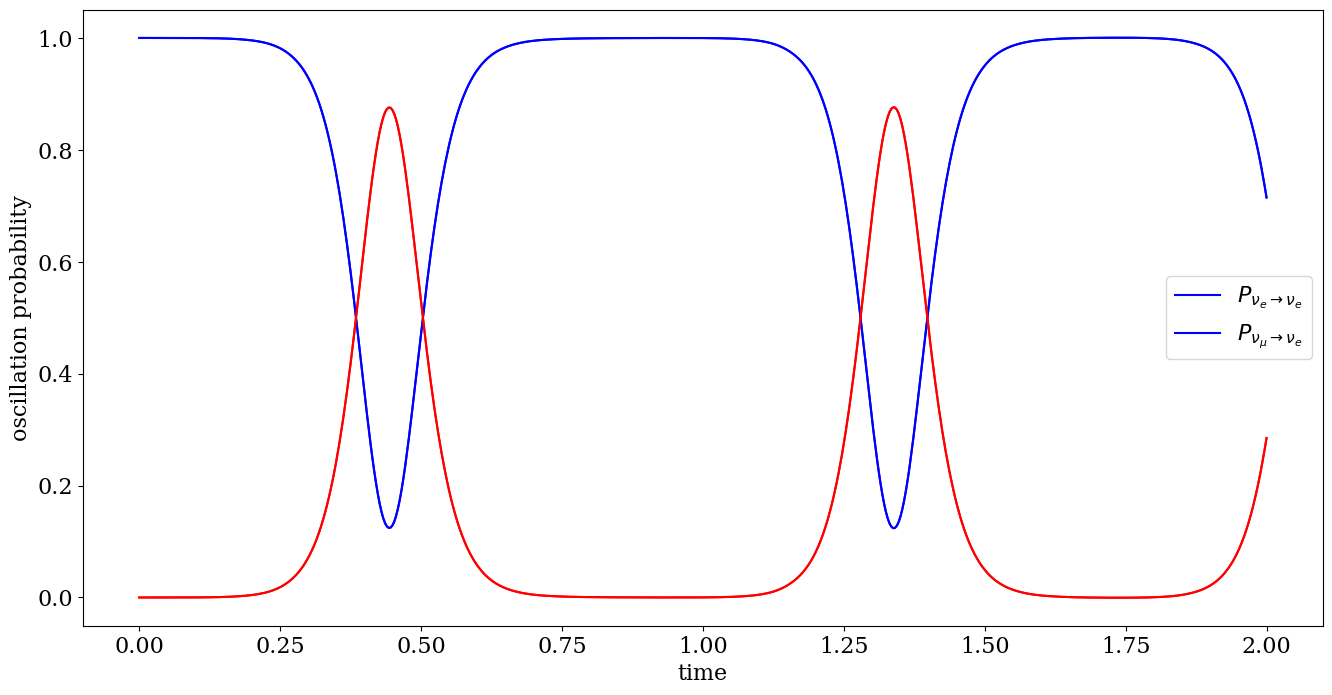

In [4]:
# test for bipolar oscillations
n_modes    = 4
n_nu       = 2
n_nubar    = 2
nu_mask    = np.array([True] *n_nu + [False]*n_nubar)
nubar_mask = np.array([False]*n_nu + [True] *n_nubar)
dmsq       = -1.0
E          = 0.1
J          = 10*np.ones((n_modes,n_modes))
#J[np.ix_(nu_mask,nubar_mask)] *= -1
#J[np.ix_(nubar_mask,nu_mask)] *= -1
t_table    = np.linspace(0,2,20*31)
sol        = P_osc_RS_bipolar(t_table, theta=0.01, omega=dmsq/(2*E)*np.ones(n_modes), lam=0, J=J, eps=0)
P_table    = np.reshape(sol.y, (n_modes,3,len(t_table)))
print(np.shape(P_table))
for k in range(n_modes):
    # # plt.plot(t_table, P_table[k,0,:], color='orange' if nu_mask[k] else 'green')
    # if nu_mask[k]:
    #     plt.plot(t_table, P_table[k,1,:], color='orange')
    # else:
    #     plt.scatter(t_table, P_table[k,1,:], color='green', s=10)
    plt.plot(t_table, 0.5*(1+P_table[k,2,:]), color='blue' if nu_mask[k] else 'red')
plt.legend([r'$P_{\nu_e \to \nu_e}$', r'$P_{\nu_\mu \to \nu_e}$'])
plt.xlabel('time')
plt.ylabel('oscillation probability')
plt.show()

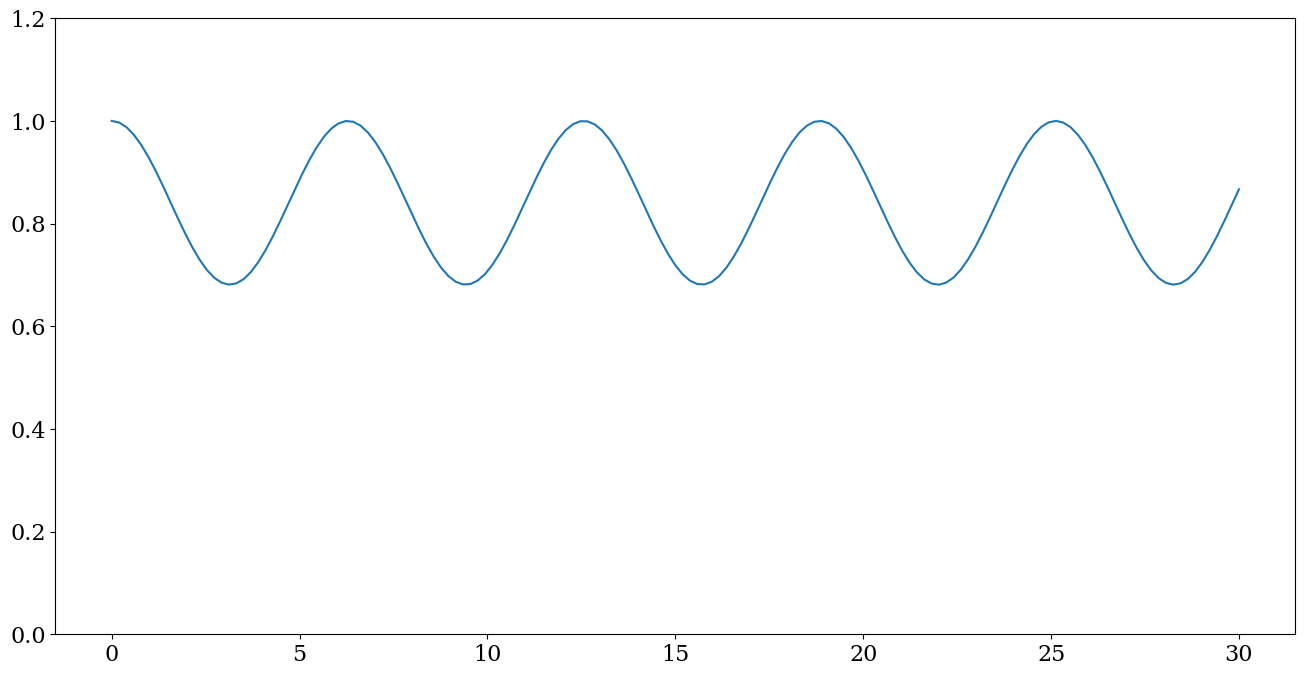

In [5]:
# test for vacuum oscillations
n_modes = 1
J       = np.zeros((n_modes,n_modes))
t_table = np.linspace(0,30,5*31)
sol = P_osc_RS(t_table, 0.3, 1.*np.ones(n_modes), 0, J)

t_table = sol.t
P_table = np.reshape(sol.y, (n_modes,3,len(t_table)))
for k in range(n_modes):
    plt.plot(t_table, 0.5*(1+P_table[k,2,:]))
plt.ylim(0,1.2)
plt.show()

## Bipolar Oscillations

Here, we simulate an interacting 4-neutrino system (2 neutrinos, 2 anti-neutrinos) in an attempt to reproduce bipolar oscillations, as described in Duan & Fuller (https://arxiv.org/abs/1001.2799).

In [6]:
def U_self_int(theta):
   """the exponential of the neutrino interaction Hamiltonian,
      see Friedland & Lunardini, https://arxiv.org/abs/hep-ph/0304055
   """
   return np.array([[np.exp(-1j*theta), 0,                          0,                          0],
                  [0,                 0.5*( 1+np.exp(-1j*theta)), 0.5*(-1+np.exp(-1j*theta)), 0],
                  [0,                 0.5*(-1+np.exp(-1j*theta)), 0.5*( 1+np.exp(-1j*theta)), 0],
                  [0,                 0,                          0,                          np.exp(-1j*theta)]])

from scipy.linalg import expm

def U_self_int_direct(theta):
   """
   The exponential of the neutrino interaction Hamiltonian,
   see Friedland & Lunardini, https://arxiv.org/abs/hep-ph/0304055
   This version forms the matrix directly
   """

   block = np.asarray([
      [2, 0, 0, 0],
      [0, 1, 1, 0],
      [0, 1, 1, 0],
      [0, 0, 0, 2]
   ])

   ht = theta / 2 * block

   return expm(-1j * ht)




In [7]:
print(U_self_int(0.1))

print(U_self_int_direct(0.1))

np.allclose(U_self_int(0.1), U_self_int_direct(0.1))

[[ 0.99500417-0.09983342j  0.        +0.j          0.        +0.j
   0.        +0.j        ]
 [ 0.        +0.j          0.99750208-0.04991671j -0.00249792-0.04991671j
   0.        +0.j        ]
 [ 0.        +0.j         -0.00249792-0.04991671j  0.99750208-0.04991671j
   0.        +0.j        ]
 [ 0.        +0.j          0.        +0.j          0.        +0.j
   0.99500417-0.09983342j]]
[[ 0.99500417-0.09983342j  0.        +0.j          0.        +0.j
   0.        +0.j        ]
 [ 0.        +0.j          0.99750208-0.04991671j -0.00249792-0.04991671j
   0.        +0.j        ]
 [ 0.        +0.j         -0.00249792-0.04991671j  0.99750208-0.04991671j
   0.        +0.j        ]
 [ 0.        +0.j          0.        +0.j          0.        +0.j
   0.99500417-0.09983342j]]


True

[[10. 10. 10. 10.]
 [10. 10. 10. 10.]
 [10. 10. 10. 10.]
 [10. 10. 10. 10.]]


100%|██████████| 49/49 [00:01<00:00, 30.91it/s] 


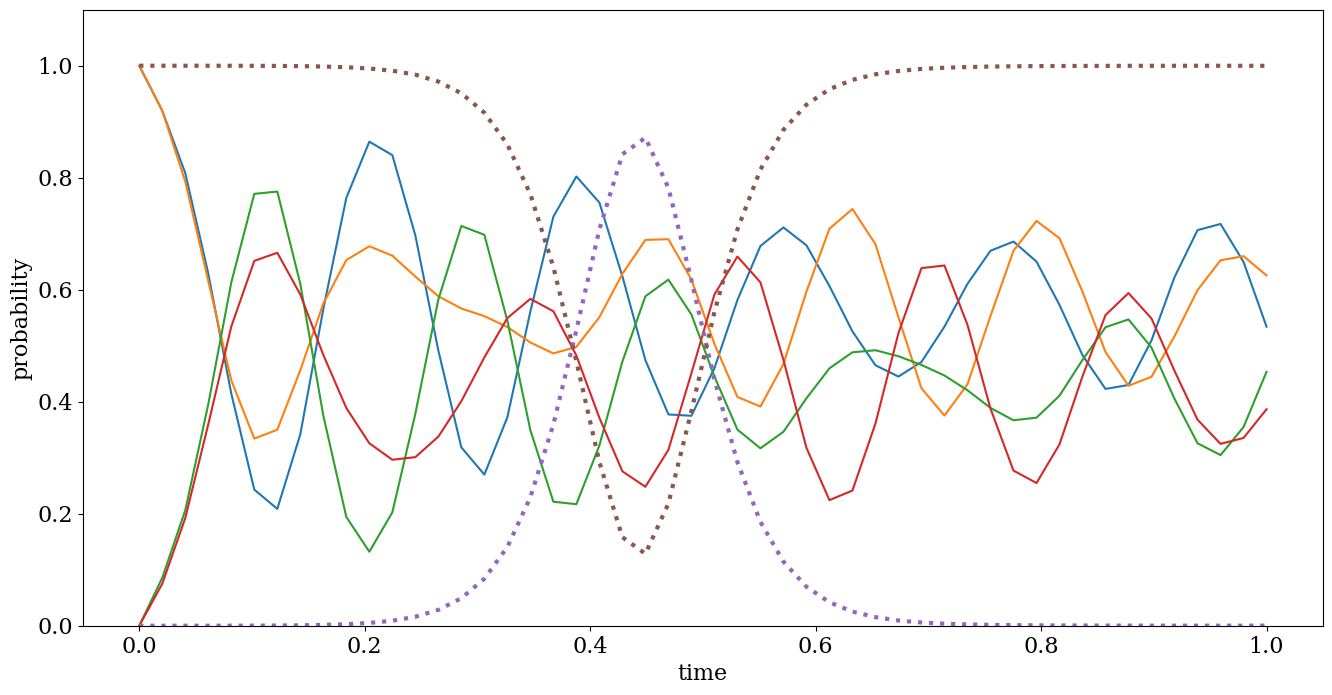

In [8]:
# self-interacting 4-neutrino system
L          = 1
t_steps    = 50
theta      = np.pi/2 - 0.01
dmsq       = 1.0
Delta      = dmsq / (2*0.1) * np.array([1.,1.,-1.,-1.])  # minus sign for the kinetic terms for antineutrinos
b          = np.array([np.sin(2*theta), 0, -np.cos(2*theta)]) # the structure of the vacuum Hamiltonian in the Pauli basis
J          = 10 * np.ones((4, 4))
nu_mask    = [True,True,False,False]
nubar_mask = [False,False,True,True]

print(J)

# mean-field solution
L_table = np.linspace(0, L, t_steps)
sol     = P_osc_RS(L_table, theta, np.array([Delta[0], -Delta[0]]), 0., 2*abs(J[::2,::2])) # factor 2 because we compare to a system with 2 nu + 2 nubar
P_table = np.reshape(sol.y, (2,3,len(L_table)))

# J[:,nubar_mask] *= -1    # minus sign for the effect of anti-neutrino modes on both neutrino and anti-neutrino modes
#                          # note that, in the quantum computing, we use the convention of Hannestad Raffelt Sigl Wong (https://arxiv.org/abs/astro-ph/0608695),
#                          # where both P and \bar{P} point in the positive z-direction for the electron flavour. In contrast, in P_osc_RS, we use the
#                          # convention from Duan, Fuller, Carlson (https://arxiv.org/abs/1001.2799), where the P(\bar\nu_e) points in the negative z-direction.

# as neutrinos don't interact with themselves in the quantum algorithm, their same-sign partner is given double weight
# J[np.ix_(nu_mask,nu_mask)]       *= 2
# J[np.ix_(nubar_mask,nubar_mask)] *= 2

# determine step size based on derivative of classical solution
L_table_quant  = np.concatenate(([0], np.cumsum(1/np.abs(np.diff(P_table[0,2])))))
L_table_quant *= L_table[-1]/L_table_quant[-1]
L_table_quant = L_table# FIXME FIXME
dt_table       = np.diff(L_table_quant)

# loop over time steps
n_qubits = 4
qc = qk.QuantumCircuit(n_qubits)
for j in np.nonzero(nubar_mask): # we use Duan and Fuller's convention here where \nu_e = |0> and \bar\nu_e = |1>
    qc.x(j)
for i in tqdm(range(len(dt_table))):
    dt = dt_table[i]

    # artificially remove entanglement by resetting each qubit to a non-entangled state
    qc_no_save = qc.remove_final_measurements(inplace=False)
    qc_no_save.data = [inst for inst in qc.data if inst.operation.name != 'save_density_matrix']
    sv = qk.quantum_info.Statevector(qc_no_save)
    rho = [ np.array(qk.quantum_info.partial_trace(sv, [j for j in range(n_qubits) if j != k])) for k in range(n_qubits) ]
    p   = [ np.real(np.array([ np.trace(sigma_1@rho[k]), np.trace(sigma_2@rho[k]), np.trace(sigma_3@rho[k]) ])) for k in range(n_qubits) ]
    
    if False:
        p[2] = np.array([P_table[1,0,i], P_table[1,1,i], P_table[1,2,i]])
        # p[2] = np.array([p[0][0], -p[0][1], p[0][2]])
        # p[1] = p[0]
        p[3] = p[2]

        p[0] = np.array([P_table[0,0,i], P_table[0,1,i], P_table[0,2,i]])
        p[1] = p[0]
        # p[3] = p[2]

    # reset qubits to a non-entangled state to emulate the mean-field picture
    qc.reset(range(n_qubits))
    for j in range(n_qubits):
        qc.ry(np.arccos(p[j][2]), j)
        qc.rz(np.arctan2(p[j][1], p[j][0]), j)

    # print(i, p[0], p[1], p[2], p[3])
    # print(i, P_table[0,:,i], P_table[1,:,i])
    
    qc.save_density_matrix(label=str(i+1))

    # strict mean-field: single-qubit evolution only, no entangling gates
    # for j in range(4):
    #     qc.rx(-dt*Delta[j]*b[0], j)
    #     qc.rz(-dt*Delta[j]*b[2], j)
    # for j in range(4):
    #     for k in range(4):
    #         # qc.rx(-dt*J[j,k] * P_table[k//2,0,i], j)
    #         # qc.ry(-dt*J[j,k] * P_table[k//2,1,i], j)
    #         # qc.rz(-dt*J[j,k] * P_table[k//2,2,i], j)
            
    #         qc.rx(-dt*J[j,k] * p[k][0], j)
    #         qc.ry(-dt*J[j,k] * p[k][1], j)
    #         qc.rz(-dt*J[j,k] * p[k][2], j)
    
    # for j in range(4):
    #     for k in range(j+1,4):
    #         qc.rx(-dt*Delta[j]*b[0]/3, j)
    #         qc.rz(-dt*Delta[j]*b[2]/3, j)
    #         qc.rx(-dt*Delta[k]*b[0]/3, k)
    #         qc.rz(-dt*Delta[k]*b[2]/3, k)

    #         qc.rx(-dt*J[j,k] * p[k][0], j)
    #         qc.ry(-dt*J[j,k] * p[k][1], j)
    #         qc.rz(-dt*J[j,k] * p[k][2], j)
    #         qc.rx(-dt*J[k,j] * p[j][0], k)
    #         qc.ry(-dt*J[k,j] * p[j][1], k)
    #         qc.rz(-dt*J[k,j] * p[j][2], k)

    # evolution allowing for entanglement
    for j in range(4):
        for k in range(j+1,4):
            qc.rx(-dt*Delta[j]*b[0]/3, j)
            qc.rz(-dt*Delta[j]*b[2]/3, j)
            qc.rx(-dt*Delta[k]*b[0]/3, k)
            qc.rz(-dt*Delta[k]*b[2]/3, k)
            # qc.unitary(U_self_int(-dt*J[j,k]), [j, k])  # FIXME I don't understand why I need an extra factor of 2 here
            qc.rxx(-dt*J[j,k], j, k)      # self-interaction
            qc.ryy(-dt*J[j,k], j, k)
            qc.rzz(-dt*J[j,k], j, k)
# end for (time steps)

# save final state
qc.save_density_matrix(label=str(i+2))

# run simulation    
sim = aer.AerSimulator(method="statevector", precision="double", zero_threshold=1e-14, validation_threshold=1e-12)
result = sim.run(qc).result()

# extract and plot results
n_qubits = qc.num_qubits
rho_reduced = [ { k : np.array(qk.quantum_info.partial_trace(result.data()[k], [q for q in range(n_qubits) if q != j])) for k in result.data().keys() } for j in range(n_qubits) ]
pp = np.array([ [[float(k), rho_reduced[j][k][0,0]] for k in rho_reduced[j].keys() ] for j in range(n_qubits) ])
pp = np.abs(np.take_along_axis(pp, pp[:,:,0].argsort(axis=1)[:,:,None], axis=1))
for j in range(n_qubits):
    plt.plot(L_table_quant, pp[j,:,1])
for k in range(len(P_table)):
    plt.plot(L_table, 0.5*(1-P_table[k,2,:]), ls=':', lw=3)
plt.ylim(0,1.1)
plt.xlabel('time')
plt.ylabel('probability')
plt.show()

### No Destruction of superposition experiment

In [9]:
from qiskit import QuantumCircuit
from utils.Collector import Collector

[[10. 10. 10. 10.]
 [10. 10. 10. 10.]
 [10. 10. 10. 10.]
 [10. 10. 10. 10.]]


100%|██████████| 49/49 [00:00<00:00, 77.15it/s] 


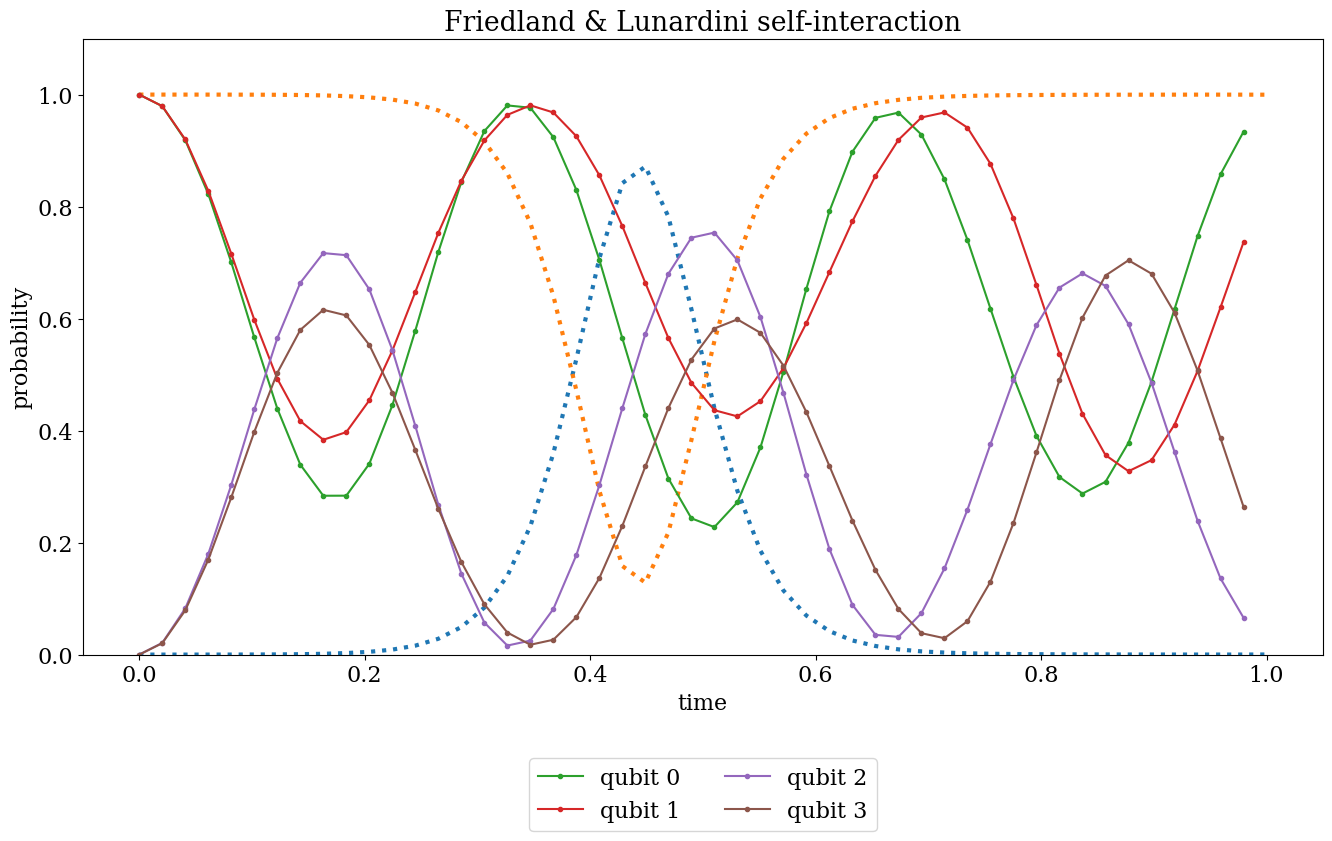

In [10]:
# self-interacting 4-neutrino system
L          = 1
t_steps    = 50
theta      = np.pi/2 - 0.01
dmsq       = 1.0
Delta      = dmsq / (2*0.1) * np.array([1.,1.,-1.,-1.])  # minus sign for the kinetic terms for antineutrinos
b          = np.array([np.sin(2*theta), 0, -np.cos(2*theta)]) # the structure of the vacuum Hamiltonian in the Pauli basis
J          = 10 * np.ones((4, 4))
nu_mask    = [True,True,False,False]
nubar_mask = [False,False,True,True]

print(J)

# mean-field solution
L_table = np.linspace(0, L, t_steps)
sol     = P_osc_RS(L_table, theta, np.array([Delta[0], -Delta[0]]), 0., 2*abs(J[::2,::2])) # factor 2 because we compare to a system with 2 nu + 2 nubar
P_table = np.reshape(sol.y, (2,3,len(L_table)))

# J[:,nubar_mask] *= -1    # minus sign for the effect of anti-neutrino modes on both neutrino and anti-neutrino modes
#                          # note that, in the quantum computing, we use the convention of Hannestad Raffelt Sigl Wong (https://arxiv.org/abs/astro-ph/0608695),
#                          # where both P and \bar{P} point in the positive z-direction for the electron flavour. In contrast, in P_osc_RS, we use the
#                          # convention from Duan, Fuller, Carlson (https://arxiv.org/abs/1001.2799), where the P(\bar\nu_e) points in the negative z-direction.

# as neutrinos don't interact with themselves in the quantum algorithm, their same-sign partner is given double weight
# J[np.ix_(nu_mask,nu_mask)]       *= 2
# J[np.ix_(nubar_mask,nubar_mask)] *= 2

# determine step size based on derivative of classical solution
L_table_quant  = np.concatenate(([0], np.cumsum(1/np.abs(np.diff(P_table[0,2])))))
L_table_quant *= L_table[-1]/L_table_quant[-1]
L_table_quant = L_table# FIXME FIXME
dt_table       = np.diff(L_table_quant)

c = Collector()

# loop over time steps
n_qubits = 4
for i in tqdm(range(len(dt_table))):
    # Initialization of the circuit
    qc = qk.QuantumCircuit(n_qubits)
    for j in np.nonzero(nubar_mask): # we use Duan and Fuller's convention here where \nu_e = |0> and \bar\nu_e = |1>
        qc.x(j)

    t = np.sum(dt_table[:i])
    c.add('t', t)
    
    # print("##################")
    # print("Time step", i, "at t =", t)
    
    # qc.save_density_matrix(label=str(i+1))

    for st in range(i):
        dt = dt_table[st]

        # evolution allowing for entanglement
        for j in range(4):
            for k in range(j+1,4):
                qc.rx(-dt*Delta[j]*b[0]/3, j)
                qc.rz(-dt*Delta[j]*b[2]/3, j)
                qc.rx(-dt*Delta[k]*b[0]/3, k)
                qc.rz(-dt*Delta[k]*b[2]/3, k)
                qc.unitary(U_self_int(-dt*J[j,k]), [j, k])  # FIXME I don't understand why I need an extra factor of 2 here
                # qc.rxx(-dt*J[j,k], j, k)      # self-interaction
                # qc.ryy(-dt*J[j,k], j, k)
                # qc.rzz(-dt*J[j,k], j, k)
    # end for (time steps)

    # save final state
    qc.save_density_matrix()

    # run simulation    
    sim = aer.AerSimulator(method="statevector", precision="double", zero_threshold=1e-14, validation_threshold=1e-12)
    result = sim.run(qc).result()

    rho = result.data()['density_matrix']

    rho_reduced = [np.array(qk.quantum_info.partial_trace(rho, [q for q in range(n_qubits) if q != j])) for j in range(n_qubits)]   

    pp = np.array([rho_reduced[j][0, 0] for j in range(n_qubits)])

    pp = np.abs(pp)

    for j in range(n_qubits):
        c.add(str(j), np.abs(pp[j]))

    # raise RuntimeError("Stop here to plot the results of the quantum simulation.")

# extract and plot results
for k in range(len(P_table)):
    plt.plot(L_table, 0.5*(1-P_table[k,2,:]), ls=':', lw=3)
for j in range(n_qubits):
    plt.plot(c.get('t'), c.get(str(j)), label=f'qubit {j}', marker='o', markersize=3, linestyle='-')
plt.ylim(0,1.1)
plt.xlabel('time')
plt.ylabel('probability')
plt.title("Friedland & Lunardini self-interaction")

# have legend under the plot
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2)
plt.show()

#### N neutrino case

In [ ]:
# self-interacting n-neutrino system
L          = 1
t_steps    = 50
theta      = np.pi/2 - 0.01
dmsq       = 1.0
n_qubits = 2
Delta = dmsq / (2 * 0.1) * np.array([1. for _ in range(n_qubits // 2)] + [-1. for _ in range(n_qubits // 2)])  # minus sign for the kinetic terms for antineutrinos
b          = np.array([np.sin(2*theta), 0, -np.cos(2*theta)]) # the structure of the vacuum Hamiltonian in the Pauli basis
J          = 10 * np.ones((n_qubits, n_qubits))
nu_mask = [True] * (n_qubits // 2) + [False] * (n_qubits // 2)
nubar_mask = [False] * (n_qubits // 2) + [True] * (n_qubits // 2)

print(J)

# mean-field solution
L_table = np.linspace(0, L, t_steps)
sol     = P_osc_RS(L_table, theta, np.array([Delta[0], -Delta[0]]), 0., 2*abs(J[::n_qubits//2,::n_qubits//2])) # factor 2 because we compare to a system with 2 nu + 2 nubar
P_table = np.reshape(sol.y, (2,3,len(L_table)))

# J[:,nubar_mask] *= -1    # minus sign for the effect of anti-neutrino modes on both neutrino and anti-neutrino modes
#                          # note that, in the quantum computing, we use the convention of Hannestad Raffelt Sigl Wong (https://arxiv.org/abs/astro-ph/0608695),
#                          # where both P and \bar{P} point in the positive z-direction for the electron flavour. In contrast, in P_osc_RS, we use the
#                          # convention from Duan, Fuller, Carlson (https://arxiv.org/abs/1001.2799), where the P(\bar\nu_e) points in the negative z-direction.

# as neutrinos don't interact with themselves in the quantum algorithm, their same-sign partner is given double weight
# J[np.ix_(nu_mask,nu_mask)]       *= 2
# J[np.ix_(nubar_mask,nubar_mask)] *= 2

# determine step size based on derivative of classical solution
L_table_quant  = np.concatenate(([0], np.cumsum(1/np.abs(np.diff(P_table[0,2])))))
L_table_quant *= L_table[-1]/L_table_quant[-1]
L_table_quant = L_table# FIXME FIXME
dt_table       = np.diff(L_table_quant)

c = Collector()

# loop over time steps
for i in tqdm(range(len(dt_table))):
    # Initialization of the circuit
    qc = qk.QuantumCircuit(n_qubits)
    for j in np.nonzero(nubar_mask): # we use Duan and Fuller's convention here where \nu_e = |0> and \bar\nu_e = |1>
        qc.x(j)

    t = np.sum(dt_table[:i])
    c.add('t', t)
    
    # print("##################")
    # print("Time step", i, "at t =", t)
    
    # qc.save_density_matrix(label=str(i+1))

    for st in range(i):
        dt = dt_table[st]

        # evolution allowing for entanglement
        for j in range(n_qubits):
            for k in range(j+1,n_qubits):
                qc.rx(-dt*Delta[j]*b[0]/3, j)
                qc.rz(-dt*Delta[j]*b[2]/3, j)
                qc.rx(-dt*Delta[k]*b[0]/3, k)
                qc.rz(-dt*Delta[k]*b[2]/3, k)
                qc.unitary(U_self_int_direct(-dt*J[j,k]), [j, k])  # FIXME I don't understand why I need an extra factor of 2 here
                # qc.rxx(-dt*J[j,k], j, k)      # self-interaction
                # qc.ryy(-dt*J[j,k], j, k)
                # qc.rzz(-dt*J[j,k], j, k)
    # end for (time steps)

    # save final state
    qc.save_density_matrix()

    # run simulation    
    method = 'statevector' if n_qubits <= 25 else 'matrix_product_state'
    sim = aer.AerSimulator(method=method, precision="double", zero_threshold=1e-14, validation_threshold=1e-12)
    result = sim.run(qc).result()

    rho = result.data()['density_matrix']

    rho_reduced = [np.array(qk.quantum_info.partial_trace(rho, [q for q in range(n_qubits) if q != j])) for j in range(n_qubits)]   

    pp = np.array([rho_reduced[j][0, 0] for j in range(n_qubits)])

    pp = np.abs(pp)

    for j in range(n_qubits):
        c.add(str(j), np.abs(pp[j]))

    # raise RuntimeError("Stop here to plot the results of the quantum simulation.")

# extract and plot results
for k in range(len(P_table)):
    plt.plot(L_table, 0.5*(1-P_table[k,2,:]), ls=':', lw=3)
for j in range(n_qubits):
    plt.plot(c.get('t'), c.get(str(j)), label=f'qubit {j}', marker='o', markersize=3, linestyle='-')
plt.ylim(0,1.1)
plt.xlabel('time')
plt.ylabel('probability')
plt.title("Friedland & Lunardini self-interaction")

# have legend under the plot
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2)
plt.show()

#### Modify the classical solution too?

In [ ]:
# self-interacting n-neutrino system
L          = 1
t_steps    = 20
theta      = np.pi/2 - 0.01
dmsq       = 1.0
n_qubits = 8
Delta = dmsq / (2 * 0.1) * np.array([1. for _ in range(n_qubits // 2)] + [-1. for _ in range(n_qubits // 2)])  # minus sign for the kinetic terms for antineutrinos
b          = np.array([np.sin(2*theta), 0, -np.cos(2*theta)]) # the structure of the vacuum Hamiltonian in the Pauli basis
J          = 10 * np.ones((n_qubits, n_qubits))
nu_mask = [True] * (n_qubits // 2) + [False] * (n_qubits // 2)
nubar_mask = [False] * (n_qubits // 2) + [True] * (n_qubits // 2)

print(J)

# mean-field solution
L_table = np.linspace(0, L, t_steps)
# sol     = P_osc_RS(L_table, theta, Delta, 0., J) # factor 2 because we compare to a system with 2 nu + 2 nubar
sol     = P_osc_RS(L_table, theta, np.array([Delta[0], -Delta[0]]), 0., n_qubits // 2 * abs(J[::n_qubits//2,::n_qubits//2])) # factor 2 because we compare to a system with 2 nu + 2 nubar
# P_table = np.reshape(sol.y, (n_qubits,3,len(L_table)))
P_table = np.reshape(sol.y, (2,3,len(L_table)))

# J[:,nubar_mask] *= -1    # minus sign for the effect of anti-neutrino modes on both neutrino and anti-neutrino modes
#                          # note that, in the quantum computing, we use the convention of Hannestad Raffelt Sigl Wong (https://arxiv.org/abs/astro-ph/0608695),
#                          # where both P and \bar{P} point in the positive z-direction for the electron flavour. In contrast, in P_osc_RS, we use the
#                          # convention from Duan, Fuller, Carlson (https://arxiv.org/abs/1001.2799), where the P(\bar\nu_e) points in the negative z-direction.

# as neutrinos don't interact with themselves in the quantum algorithm, their same-sign partner is given double weight
# J[np.ix_(nu_mask,nu_mask)]       *= 2
# J[np.ix_(nubar_mask,nubar_mask)] *= 2

# determine step size based on derivative of classical solution
L_table_quant  = np.concatenate(([0], np.cumsum(1/np.abs(np.diff(P_table[0,2])))))
L_table_quant *= L_table[-1]/L_table_quant[-1]
L_table_quant = L_table# FIXME FIXME
dt_table       = np.diff(L_table_quant)

c = Collector()

# loop over time steps
for i in tqdm(range(len(dt_table))):
    # Initialization of the circuit
    qc = qk.QuantumCircuit(n_qubits)
    for j in np.nonzero(nubar_mask): # we use Duan and Fuller's convention here where \nu_e = |0> and \bar\nu_e = |1>
        qc.x(j)

    t = np.sum(dt_table[:i])
    c.add('t', t)
    
    # print("##################")
    # print("Time step", i, "at t =", t)
    
    # qc.save_density_matrix(label=str(i+1))

    for st in range(i):
        dt = dt_table[st]

        # evolution allowing for entanglement
        for j in range(n_qubits):
            for k in range(j+1,n_qubits):
                qc.rx(-dt*Delta[j]*b[0]/3, j)
                qc.rz(-dt*Delta[j]*b[2]/3, j)
                qc.rx(-dt*Delta[k]*b[0]/3, k)
                qc.rz(-dt*Delta[k]*b[2]/3, k)
                qc.unitary(U_self_int_direct(-dt*J[j,k]), [j, k])  # FIXME I don't understand why I need an extra factor of 2 here
                # qc.rxx(-dt*J[j,k], j, k)      # self-interaction
                # qc.ryy(-dt*J[j,k], j, k)
                # qc.rzz(-dt*J[j,k], j, k)
    # end for (time steps)

    # save final state
    qc.save_density_matrix()

    # run simulation    
    method = 'statevector' if n_qubits <= 25 else 'matrix_product_state'
    sim = aer.AerSimulator(method=method, precision="double", zero_threshold=1e-14, validation_threshold=1e-12)
    result = sim.run(qc).result()

    rho = result.data()['density_matrix']

    rho_reduced = [np.array(qk.quantum_info.partial_trace(rho, [q for q in range(n_qubits) if q != j])) for j in range(n_qubits)]   

    pp = np.array([rho_reduced[j][0, 0] for j in range(n_qubits)])

    pp = np.abs(pp)

    for j in range(n_qubits):
        c.add(str(j), np.abs(pp[j]))

    # raise RuntimeError("Stop here to plot the results of the quantum simulation.")

# extract and plot results
for k in range(len(P_table)):
    plt.plot(L_table, 0.5*(1-P_table[k,2,:]), ls=':', lw=3)
# for j in range(n_qubits):
#     plt.plot(c.get('t'), c.get(str(j)), label=f'qubit {j}', marker='o', markersize=3, linestyle='-')
nu_mean = np.mean([c.get(str(j)) for j in range(n_qubits) if nu_mask[j]], axis=0)
nubar_mean = np.mean([c.get(str(j)) for j in range(n_qubits) if nubar_mask[j]], axis=0)
plt.plot(c.get('t'), nu_mean, label='mean $\nu_e$', marker='o', markersize=3, linestyle='-')
plt.plot(c.get('t'), nubar_mean, label='mean $\bar\nu_e$', marker='o', markersize=3, linestyle='-')

plt.ylim(0,1.1)
plt.xlabel('time')
plt.ylabel('probability')
plt.title("Friedland & Lunardini self-interaction")

# have legend under the plot
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2)
plt.show()

[[10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10.]
 [10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10.]
 [10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10.]
 [10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10.]
 [10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10.]
 [10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10.]
 [10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10.]
 [10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10.]
 [10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10.]
 [10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10.]
 [10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10.]
 [10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10.]
 [10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10.]
 [10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10.]]


  5%|▌         | 1/19 [00:31<09:27, 31.54s/it]